# Diabetes Prediction using K-Nearest Neighbors (KNN)

## Definition

K-Nearest Neighbors (KNN) ek Supervised Machine Learning Algorithm hai jo:

- Classification ke liye use hota hai

- Regression ke liye bhi use hota hai

Ye ek distance-based algorithm hai.

## KNN Ka Core 

- Jab koi naya data point aata hai:

- Ye sab training data se distance calculate karta hai

- Sabse kareeb K neighbors select karta hai

- Majority vote karta hai (classification mein)

- Ya average leta hai (regression mein)

## "K" Ka Matlab

K = Kitne nearest neighbors consider karne hain

Example:

- K = 3 → 3 nearest patients dekhe jayenge

- K = 5 → 5 nearest patients dekhe jayenge

Usually odd number use hota hai (3,5,7) taake tie na ho.

# Problem Statement
Hume predict karna hai:

Patient diabetic hai ya nahi

Target column:

- 0 → Not Diabetic

- 1 → Diabetic

# Step 1 — Import Libraries
Explanation:

- pandas → data load karne ke liye

- numpy → numerical operations

- matplotlib, seaborn → visualization

- sklearn → ML tools

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2 — Load Dataset
Explanation:

- Dataset load kiya aur first 5 rows dekhi.


In [3]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Step 3 — Basic Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Step 4 — Zero Values Handle Karna

Medical data mein kuch columns mein 0 unrealistic hota hai:

- Glucose

- BloodPressure

- SkinThickness

- Insulin

- BMI

Inko median se replace karte hain:

Explanation:

- Zero values ko median se replace kiya taake data realistic ho.

In [7]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    data[col] = data[col].replace(0, data[col].median())

# Step 5 — Define Features and 

Explanation:

- X → input features

- y → output (diabetic ya nahi)

In [9]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Step 6 — Train Test Split
Explanation:

- 80% training data

- 20% testing data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7 — Feature Scaling (Very Important)

Explanation:

- KNN distance use karta hai.
- Isliye features ko same scale par lana zaroori hai.

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8 — Apply KNN Model
Explanation:

K = 5 choose kiya

fit() → model train ho gaya

In [12]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Step 9 — Prediction

In [21]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

# Step 10 — Model Evaluation

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


In [15]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[80 19]
 [19 36]]


In [16]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



# Step 11 — Best K Find Karna

Explanation:

- K ko 1 se 20 tak test kiya
- Jo K highest accuracy de — woh best K

In [17]:
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

print(accuracies)

[0.6428571428571429, 0.6493506493506493, 0.7272727272727273, 0.6818181818181818, 0.7532467532467533, 0.7272727272727273, 0.7467532467532467, 0.7467532467532467, 0.7337662337662337, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7532467532467533, 0.7532467532467533, 0.7662337662337663, 0.7727272727272727, 0.7922077922077922, 0.7857142857142857, 0.7727272727272727, 0.7792207792207793]


In [18]:
# Step 12 — Accuracy Graph

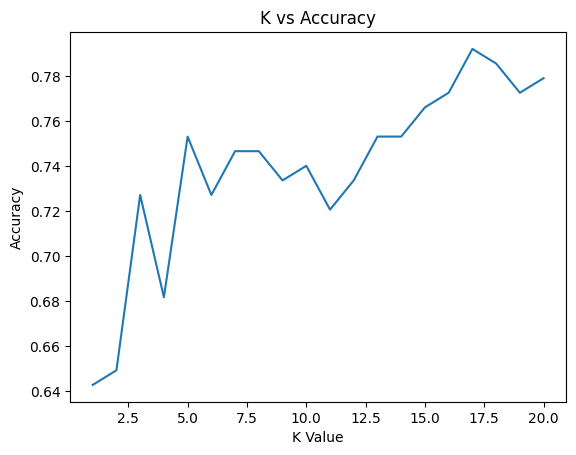

In [19]:
plt.plot(range(1,21), accuracies)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()